In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [61]:
def leggere_file():
    """
    Legge tutti i file CSV necessari.
    """
    df_sales = pd.read_csv("/Users/chiarapareschi/Desktop/SALES.csv")
    df_company = pd.read_csv("/Users/chiarapareschi/Desktop/COMPANY_LOOKUP.csv")
    df_items = pd.read_csv("/Users/chiarapareschi/Desktop/ITEM_LOOKUP.csv")
    df_lines = pd.read_csv("/Users/chiarapareschi/Desktop/ITEM_BUSINESS_LINE_LOOKUP.csv")
    df_customers = pd.read_csv("/Users/chiarapareschi/Desktop/CUSTOMER_LOOKUP.csv")
    df_area = pd.read_csv("/Users/chiarapareschi/Desktop/AREA_MANAGER_LOOKUP.csv")

    return df_sales, df_company, df_items, df_lines, df_customers, df_area

def rimuovere_duplicati(df):
    """
    Rimuove i duplicati dal dataframe.
    """
    return df.drop_duplicates()

def merge_data(df_sales, df_company, df_items, df_lines, df_customers, df_area):
    """
    Unisce tutti i dataframe tramite join.
    """
    df = df_sales.merge(df_company, on="ID_COMPANY", how="left")
    df = df.merge(df_items, on="IDS_ITEM", how="left")
    df = df.merge(df_lines, on="ID_BUSINESS_LINE", how="left")
    df = df.merge(df_customers, on="IDS_CUSTOMER", how="left")
    df = df.merge(df_area, on="ID_AREA_MANAGER", how="left")
    return df

def clean_date(df, col, min_date, max_date):
    """
    Converte una colonna in datetime, rimuove date fuori range
    e riempie valori mancanti con la mediana.
    """
    d = pd.to_datetime(df[col], format="%Y%m%d", errors="coerce")
    mask = (d < min_date) | (d > max_date)
    d[mask] = pd.NaT
    d = d.fillna(d.median())
    return d


def pulisce_date(df):
    """
    Pulisce le colonne di data.
    """
    min_date = pd.Timestamp("1900-01-01")
    max_date = pd.Timestamp("today")

    df["ID_INVOICE_DATE"] = clean_date(df, "ID_INVOICE_DATE", min_date, max_date)
    df["ID_ORDER_DATE"] = clean_date(df, "ID_ORDER_DATE", min_date, max_date)

    return df

In [63]:
def analisi_statistica_completa(df):
    """
    Esegue un'analisi statistica completa del dataset.
    """
    df = df.copy()

    print("\n==============================")
    print("INFO GENERALE DATASET")
    print("==============================")
    print(df.info())

    print("\n==============================")
    print("STATISTICHE DESCRITTIVE")
    print("==============================")
    print(df.describe())

    print("\n==============================")
    print("VALORI MANCANTI")
    print("==============================")
    print(df.isnull().sum())

    # DISTRIBUZIONE TARGET
    if "VAL_REVENUES" in df.columns:
        plt.figure()
        sns.histplot(df["VAL_REVENUES"], kde=True)
        plt.title("Distribuzione VAL_REVENUES")
        plt.show()

        plt.figure()
        sns.boxplot(x=df["VAL_REVENUES"])
        plt.title("Boxplot VAL_REVENUES")
        plt.show()

    # OUTLIER ANALYSIS
    if "VAL_REVENUES" in df.columns:
        q1 = df["VAL_REVENUES"].quantile(0.25)
        q3 = df["VAL_REVENUES"].quantile(0.75)
        iqr = q3 - q1

        outliers = df[
            (df["VAL_REVENUES"] < q1 - 1.5 * iqr) |
            (df["VAL_REVENUES"] > q3 + 1.5 * iqr)
        ]

        print("\n==============================")
        print("OUTLIER")
        print("==============================")
        print(f"Numero outlier: {len(outliers)}")

    # ANALISI CORRELAZIONE
    print("\n==============================")
    print("MATRICE DI CORRELAZIONE")
    print("==============================")
    matrix = df.corr(numeric_only=True)

    plt.figure(figsize=(10,8))
    sns.heatmap(matrix, cmap="coolwarm", annot=False)
    plt.title("Correlation Matrix")
    plt.show()

    # ANALISI TEMPORALE (se presente)
    if "ID_ORDER_DATE" in df.columns:
        df["ID_ORDER_DATE"] = pd.to_datetime(df["ID_ORDER_DATE"], errors="coerce")

        df["ANNO"] = df["ID_ORDER_DATE"].dt.year
        df["MESE"] = df["ID_ORDER_DATE"].dt.month

        if "VAL_REVENUES" in df.columns:
            trend = df.groupby("MESE")["VAL_REVENUES"].mean().reset_index()

            plt.figure()
            plt.plot(trend["MESE"], trend["VAL_REVENUES"], marker="o")
            plt.title("Trend mensile medio")
            plt.xlabel("Mese")
            plt.ylabel("Revenue media")
            plt.show()

    # ANALISI VARIABILI CATEGORICHE
    categorical_cols = [
        col for col in df.columns
        if df[col].dtype == "object"
    ]

    for col in categorical_cols[:5]:  # limito per non fare troppi grafici
        if "VAL_REVENUES" in df.columns:
            top = df.groupby(col)["VAL_REVENUES"].mean().sort_values(ascending=False).head(10)

            plt.figure()
            top.plot(kind="bar")
            plt.title(f"{col} vs Revenue media")
            plt.xticks(rotation=45)
            plt.show()


In [65]:
def statistiche_dettagliate(df):
    """
    Calcola statistiche principali (media, minimo, massimo, varianza, dev_std, mediana, moda)
    e costruisce tabelle di frequenze per tutte le colonne numeriche e categoriche.
    """

    df = df.copy()

    print("\n==============================")
    print("STATISTICHE NUMERICHE DETTAGLIATE")
    print("==============================")

    numeric_cols = df.select_dtypes(include=np.number).columns
    for col in numeric_cols:
        s = df[col].dropna()
        media = s.mean()
        minimo = s.min()
        massimo = s.max()
        varianza = s.var(ddof=0)      
        dev_std = s.std(ddof=0)      
        mediana = s.median()
        moda = s.mode().tolist()

        print(f"\nColonna: {col}")
        print(f"Media = {media:.2f}")
        print(f"Minimo = {minimo}")
        print(f"Massimo = {massimo}")
        print(f"Varianza = {varianza:.2f}")
        print(f"Deviazione standard = {dev_std:.2f}")
        print(f"Mediana = {mediana}")
        print(f"Moda = {moda}")

        # Tabella frequenze
        freq_ass = s.value_counts().sort_index()
        freq_rel = s.value_counts(normalize=True).sort_index()
        freq_rel_cum = freq_rel.cumsum()

        tabella = pd.DataFrame({
            "Modalità": freq_ass.index,
            "Freq Ass": freq_ass.values,
            "Freq Rel (%)": (freq_rel.values * 100).round(1),
            "Freq Rel Cum (%)": (freq_rel_cum.values * 100).round(1)
        })

        tabella.index = range(1, len(tabella) + 1)
        tabella.index.name = "Indice"

        print("\nTabella frequenze:")
        print(tabella)

    # Frequenze per le variabili categoriche (object)
    print("\n==============================")
    print("FREQUENZE VARIABILI CATEGORICHE")
    print("==============================")

    categorical_cols = df.select_dtypes(include='object').columns
    for col in categorical_cols:
        s = df[col].dropna()
        freq_ass = s.value_counts().head(10)  # top 10 valori
        freq_rel = s.value_counts(normalize=True).head(10)
        freq_rel_cum = freq_rel.cumsum()

        tabella = pd.DataFrame({
            "Modalità": freq_ass.index,
            "Freq Ass": freq_ass.values,
            "Freq Rel (%)": (freq_rel.values * 100).round(1),
            "Freq Rel Cum (%)": (freq_rel_cum.values * 100).round(1)
        })
        tabella.index = range(1, len(tabella) + 1)
        tabella.index.name = "Indice"

        print(f"\nColonna: {col}")
        print(tabella)

In [67]:
def data_profiling(df, target_col="VAL_REVENUES"):
    print("\n==============================")
    print("1. DIMENSIONE DATASET")
    print("==============================")
    print(df.shape)

    print("\n==============================")
    print("2. VALORI MANCANTI")
    print("==============================")
    missing = df.isna().sum()
    print(missing[missing > 0].sort_values(ascending=False))

    print("\n==============================")
    print("3. STATISTICHE NUMERICHE")
    print("==============================")
    display(df.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))

    print("\n==============================")
    print("4. DISTRIBUZIONE TARGET")
    print("==============================")
    plt.figure(figsize=(10,4))
    sns.histplot(df[target_col], bins=50, kde=True)
    plt.title(f"Distribuzione di {target_col}")
    plt.show()

    print("\n==============================")
    print("5. TOP 10 CLIENTI PER REVENUE")
    print("==============================")
    if "IDS_CUSTOMER" in df.columns:
        top_customers = df.groupby("IDS_CUSTOMER")[target_col].sum().sort_values(ascending=False).head(10)
        print(top_customers)

    print("\n==============================")
    print("6. TOP 10 PRODOTTI PER REVENUE")
    print("==============================")
    if "IDS_ITEM" in df.columns:
        top_items = df.groupby("IDS_ITEM")[target_col].sum().sort_values(ascending=False).head(10)
        print(top_items)

    print("\n==============================")
    print("7. CARDINALITÀ DELLE CATEGORIE")
    print("==============================")
    cat_cols = df.select_dtypes(include=["object"]).columns
    for col in cat_cols:
        print(f"{col}: {df[col].nunique()} valori unici")

    print("\n==============================")
    print("8. CORRELAZIONI CON IL TARGET")
    print("==============================")
    corr = df.corr(numeric_only=True)[target_col].sort_values(ascending=False)
    print(corr.head(15))
    print("\n--- Variabili meno correlate ---")
    print(corr.tail(15))

    print("\n==============================")
    print("9. HEATMAP CORRELAZIONI (NUMERICHE)")
    print("==============================")
    plt.figure(figsize=(12,8))
    sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm", center=0)
    plt.show()

    print("\n==============================")
    print("10. DISTRIBUZIONE TEMPORALE")
    print("==============================")
    if "ID_ORDER_DATE" in df.columns:
        df["ID_ORDER_DATE"].value_counts().sort_index().plot(figsize=(12,4))
        plt.title("Distribuzione temporale degli ordini")
        plt.show()

In [69]:
def plot_trend(df, revenue_col="VAL_REVENUES"):
    """
    Disegna l'andamento medio della revenue per mese.
    """
    df = df.copy()

    trend = df.groupby("MESE")[revenue_col].mean().reset_index()

    plt.figure(figsize=(12,5))
    plt.plot(trend["MESE"], trend[revenue_col], marker="o", linewidth=2)
    plt.xticks(ticks=trend["MESE"], labels=trend["MESE"].astype(str).str.zfill(2))
    plt.title("Andamento medio mensile della revenue")
    plt.xlabel("Mese")
    plt.ylabel("Revenue media")
    plt.show()


1. DIMENSIONE DATASET
(213, 16)

2. VALORI MANCANTI
Series([], dtype: int64)

3. STATISTICHE NUMERICHE


,ID_COMPANY,ID_ORDER_NUM,ID_ORDER_DATE,ID_INVOICE_DATE,VAL_REVENUES,VAL_COST
count,213.000000,2.130000e+02,213,213,213.000000,213.000000
mean,37501.971831,2.555459e+07,2025-08-23 14:59:09.295774720,2025-09-04 09:54:55.774647808,34953.296103,17310.975369
min,40.000000,2.540005e+07,2025-01-08 00:00:00,2025-01-09 00:00:00,20329.610000,7096.634800
1%,40.000000,2.540008e+07,2025-01-10 00:00:00,2025-01-17 07:40:48,20392.377600,8335.548312
5%,40.000000,2.540024e+07,2025-02-04 14:24:00,2025-02-21 19:12:00,22099.360000,9506.809700
25%,40.000000,2.540153e+07,2025-05-15 00:00:00,2025-06-06 00:00:00,25666.000000,11998.000000
50%,40.000000,2.543545e+07,2025-09-16 00:00:00,2025-09-26 00:00:00,32724.000000,17343.753300
75%,80640.000000,2.547181e+07,2025-11-24 00:00:00,2025-12-11 00:00:00,39596.400000,20171.504800
95%,80640.000000,2.641780e+07,2026-02-14 14:24:00,2026-02-10 19:12:00,53982.600000,26225.825560
99%,80640.000000,2.642430e+07,2026-03-09 21:07:12,2026-03-05 00:57:36,97175.592000,52959.009896



4. DISTRIBUZIONE TARGET


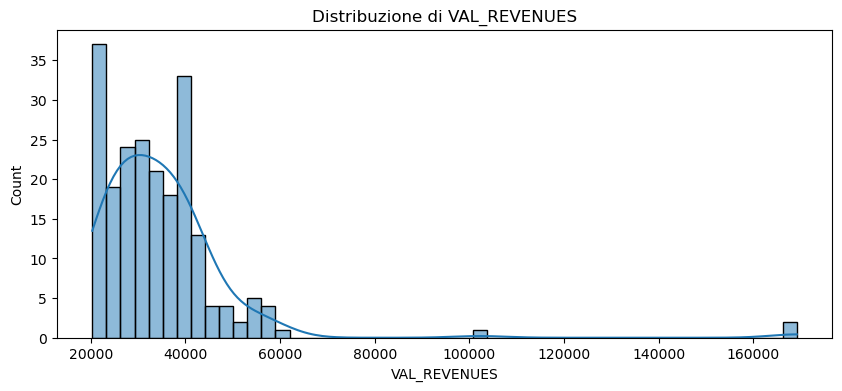


5. TOP 10 CLIENTI PER REVENUE
IDS_CUSTOMER
00040-10277     607519.03
80640-207312    539884.69
00040-45887     529633.26
80640-308899    338320.80
80640-615382    327394.40
80640-444800    252062.48
80640-459504    250918.86
00040-209369    234561.71
00040-42576     213016.17
80640-289134    161114.00
Name: VAL_REVENUES, dtype: float64

6. TOP 10 PRODOTTI PER REVENUE
IDS_ITEM
7245498-W401MAG    1420413.29
7273238-405MAG     1043530.28
7344923-W401MAG     713458.85
7481581-405MAG      678206.17
7245502-W401MAG     611243.13
7479346-405MAG      424134.50
7270011-W401MAG     338320.80
7195806-405MAG      320975.88
7273191-405MAG      307085.40
7492608-W401MAG     266079.52
Name: VAL_REVENUES, dtype: float64

7. CARDINALITÀ DELLE CATEGORIE
IDS_CUSTOMER: 71 valori unici
IDS_ITEM: 27 valori unici
DESC_COMPANY: 2 valori unici
DESC_ITEM: 27 valori unici
ID_BUSINESS_LINE: 2 valori unici
DESC_BUSINESS_LINE: 2 valori unici
DESC_CUSTOMER: 71 valori unici
ID_COUNTRY: 3 valori unici
ID_AREA_MANAGER

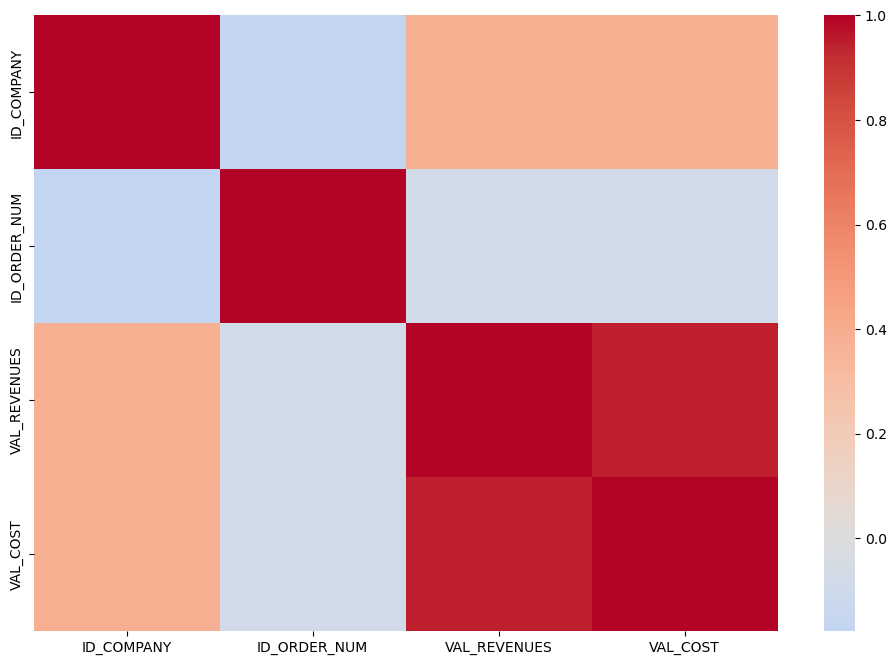


10. DISTRIBUZIONE TEMPORALE


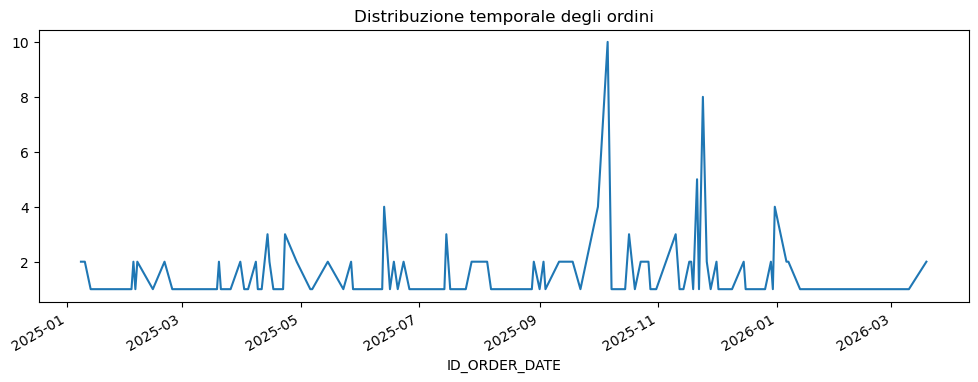


INFO GENERALE DATASET
<class 'pandas.core.frame.DataFrame'>
Index: 213 entries, 0 to 4470
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   ID_COMPANY          213 non-null    int64         
 1   ID_ORDER_NUM        213 non-null    int64         
 2   IDS_CUSTOMER        213 non-null    object        
 3   IDS_ITEM            213 non-null    object        
 4   ID_ORDER_DATE       213 non-null    datetime64[ns]
 5   ID_INVOICE_DATE     213 non-null    datetime64[ns]
 6   VAL_REVENUES        213 non-null    float64       
 7   VAL_COST            213 non-null    float64       
 8   DESC_COMPANY        213 non-null    object        
 9   DESC_ITEM           213 non-null    object        
 10  ID_BUSINESS_LINE    213 non-null    object        
 11  DESC_BUSINESS_LINE  213 non-null    object        
 12  DESC_CUSTOMER       213 non-null    object        
 13  ID_COUNTRY          213 non-nul

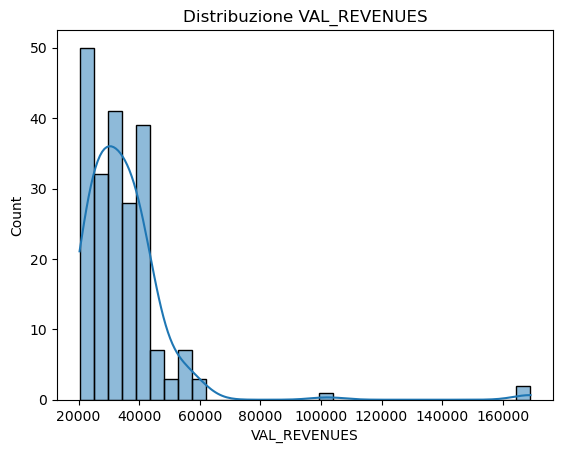

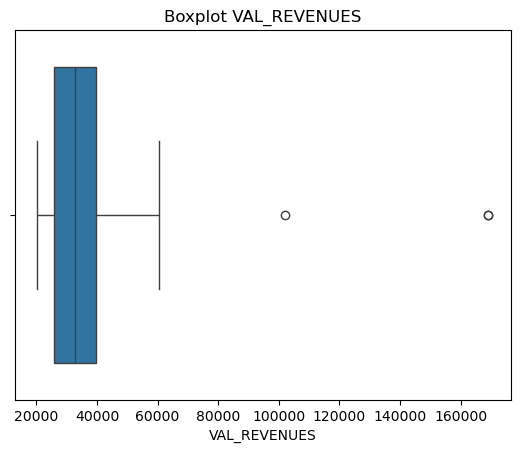


OUTLIER
Numero outlier: 3

MATRICE DI CORRELAZIONE


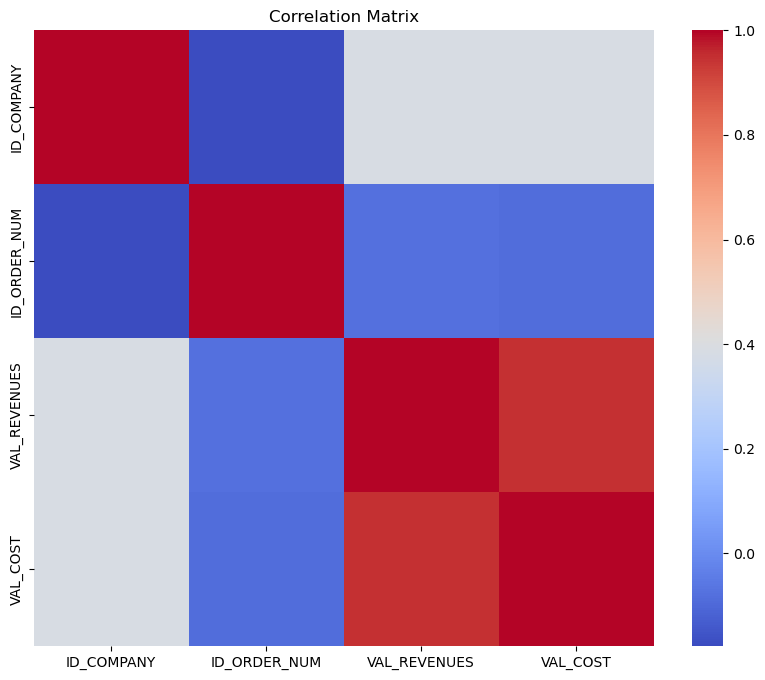

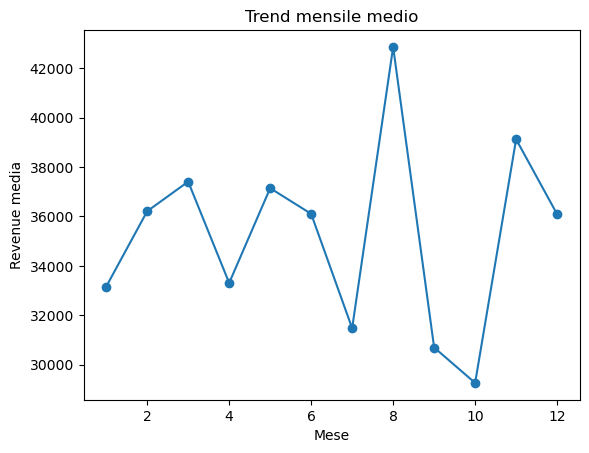

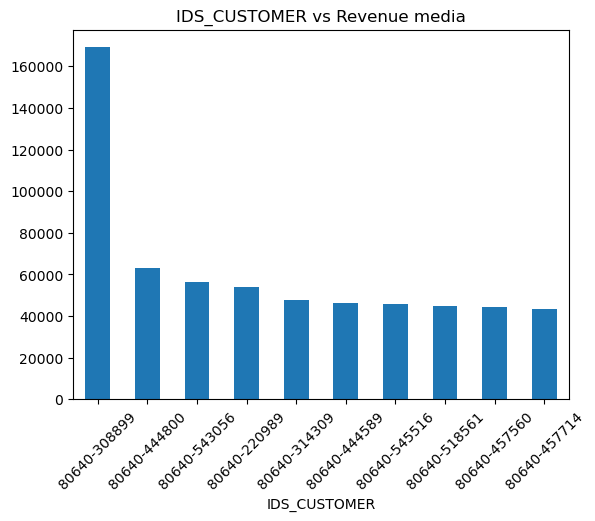

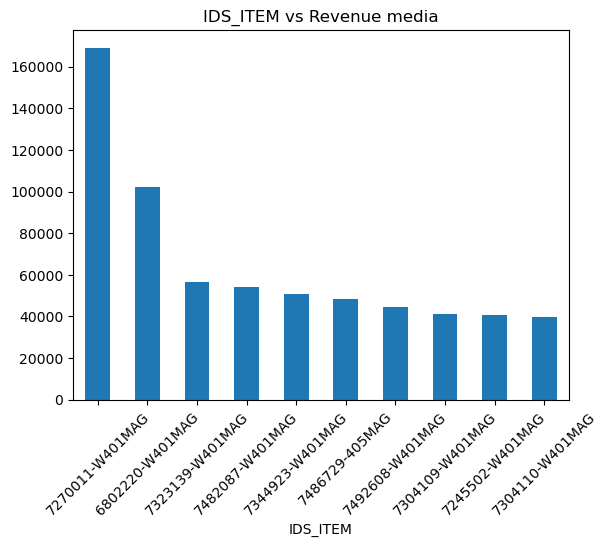

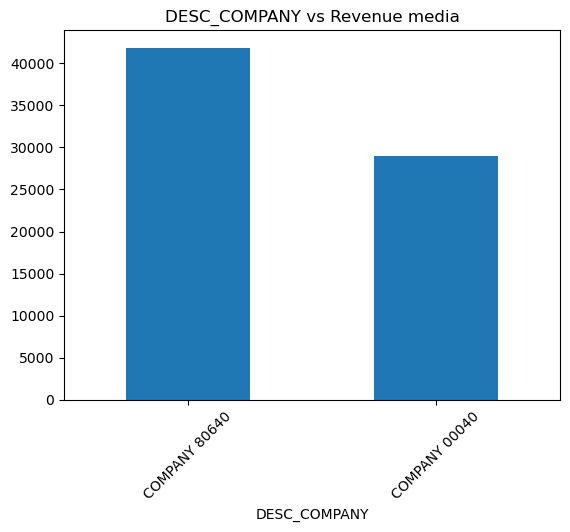

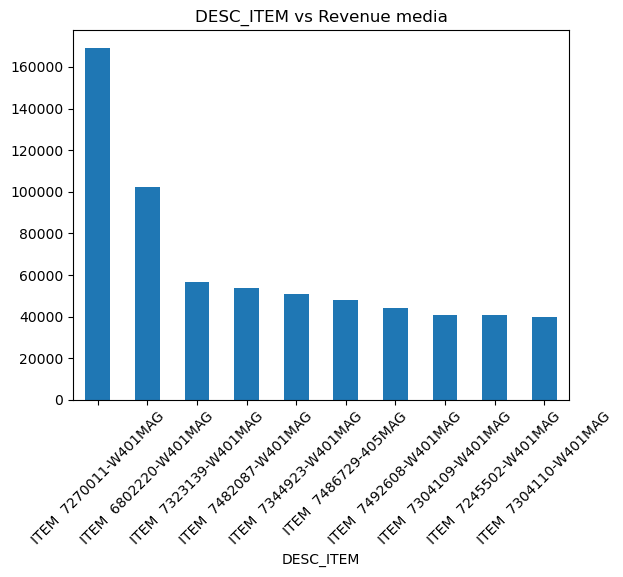

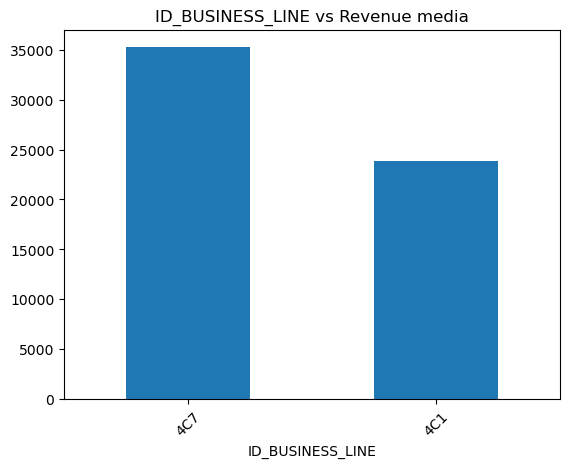


STATISTICHE NUMERICHE DETTAGLIATE

Colonna: ID_COMPANY
Media = 37501.97
Minimo = 40
Massimo = 80640
Varianza = 1616035596.11
Deviazione standard = 40199.95
Mediana = 40.0
Moda = [40]

Tabella frequenze:
        Modalità  Freq Ass  Freq Rel (%)  Freq Rel Cum (%)
Indice                                                    
1             40       114          53.5              53.5
2          80640        99          46.5             100.0

Colonna: ID_ORDER_NUM
Media = 25554589.18
Minimo = 25400051
Massimo = 26426822
Varianza = 107660521062.94
Deviazione standard = 328116.63
Mediana = 25435451.0
Moda = [25402070, 25402388, 25471810]

Tabella frequenze:
        Modalità  Freq Ass  Freq Rel (%)  Freq Rel Cum (%)
Indice                                                    
1       25400051         1           0.5               0.5
2       25400072         1           0.5               0.9
3       25400075         1           0.5               1.4
4       25400082         1           0.5       

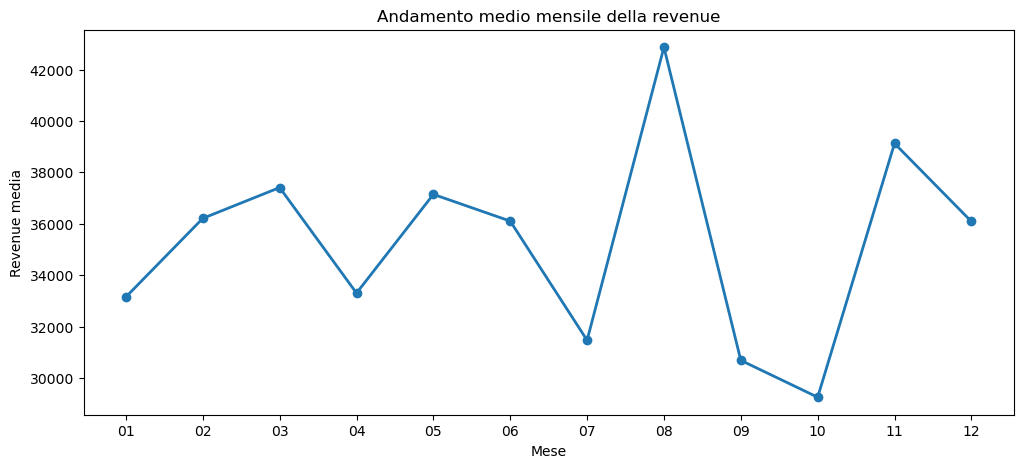

In [71]:
def main():
    """
    Pipeline principale per analisi statistica (EDA).
    """
    #Leggi file
    df_sales, df_company, df_items, df_lines, df_customers, df_area = leggere_file()

    #Merge dataset
    df = merge_data(df_sales, df_company, df_items, df_lines, df_customers, df_area)

    #Pulizia dati
    df = rimuovere_duplicati(df)
    df = pulisce_date(df)
    
    data_profiling(df, target_col="VAL_REVENUES")
  
    #Analisi statistica completa
    analisi_statistica_completa(df)

    #Analisi statistica dettagliata 
    statistiche_dettagliate(df)

    #Grafico trend
    if "ID_ORDER_DATE" in df.columns:
        df["MESE"] = df["ID_ORDER_DATE"].dt.month
        plot_trend(df)

    return df

if __name__ == "__main__":
    main()